In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, hamming_loss
from tabulate import tabulate

# Load dataset
df = pd.read_csv('data/cleaned_malaria.csv')

# Display the first few rows
print("\n📋 Initial Dataset:")
print(tabulate(df.head(), headers='keys', tablefmt='grid'))


FileNotFoundError: [Errno 2] No such file or directory: 'data/cleaned_malaria.csv'

In [205]:
# Load dataset

df = pd.read_csv('cleaned_malaria.csv')

# Display the first few rows
print("\n📋 Initial Dataset:")
print(tabulate(df.head(), headers='keys', tablefmt='grid'))


📋 Initial Dataset:
+----+-------+----------+------------------------------------------------------------------------------+--------------+------------------------+---------------------+-------------------------+
|    |   AGE | GENDER   | SYMPTOMS                                                                     |   WEIGHT(kg) |   TEMPERATURE(degreec) | Underlying Issues   | PRESCRIBED MEDICATION   |
+====+=======+==========+==============================================================================+==============+========================+=====================+=========================+
|  0 |    23 | M        | cough , headache, Body weakness                                              |      72.7    |                   36.4 | none                | ACT tablet              |
+----+-------+----------+------------------------------------------------------------------------------+--------------+------------------------+---------------------+-------------------------+
|  1 |    18 | 

# Malaria Drug Recommender System: Data Preparation and Model Selection

This notebook explores, cleans, and prepares malaria patient data, then compares multiple machine learning models to select the best for drug recommendation.

In [206]:
# Code to check the unique values in the 'Underlying Issues' column
unique_issues = set()
df['Underlying Issues'].dropna().apply(lambda x: unique_issues.add(x.strip().lower()))
print("Unique values in 'Underlying Issues' column:")
print(sorted(unique_issues))
print(f"Total unique values: {len(unique_issues)}")

Unique values in 'Underlying Issues' column:
['asthma', 'diabetes', 'none', 'ulcer']
Total unique values: 4


In [207]:
# Get all unique symptom words from the SYMPTOMS column
unique_symptoms = set()
df['SYMPTOMS'].dropna().apply(lambda x: [unique_symptoms.add(sym.strip().lower()) for sym in x.split(',')])
print("All unique symptoms:")
print(sorted(unique_symptoms))
print(f"\nTotal unique symptoms: {len(unique_symptoms)}")

All unique symptoms:
['', 'abdominal pain', 'abdominal pain. body weakness', 'acute diarihea', 'anorexia', 'back pain', 'bitter taste', 'bloody vomiting', 'blury vision', 'body pain', 'body pain catarrh', 'body pain. chest pain', 'body rashes', 'body weakness', 'boil in the ear', 'bone pain', 'catarrh', 'chest pain', 'cold', 'constant weakness', 'cough', 'diarrhea', 'difficulty in breathing', 'dizziness', 'dizzinesss', 'drowsy', 'dry cough', 'dyspnoea', 'elevated high blood pressure', 'elivated bp', 'eoigastric pain', 'epigastric pain', 'evening fever', 'eye ache', 'eye pain', 'eyepain', 'fatigue', 'feeble', 'fever', 'fever catarrh', 'fever headache', 'fitigue', 'fiver', 'heachache', 'heache', 'headache', 'headache. fever', 'headaches', 'headahe', 'herpes', 'herpes of the lips', 'ill looking', 'increased vaginal discharge', 'inflamed tonsils', 'insomnia', 'irritability', 'itching', 'itching eye', 'itchy vulva', 'joint aches', 'joint pain', 'joint pains', 'joint-pain', 'jointpain', 'lef

In [208]:

# Count the frequency of each unique symptom word in the SYMPTOMS column
from collections import Counter

symptom_counter = Counter()
df['SYMPTOMS'].dropna().apply(
    lambda x: symptom_counter.update([sym.strip().lower() for sym in x.split(',') if sym.strip()])
)

# Print each symptom and its count, sorted by count descending
print("Symptom counts (descending):")
for symptom, count in symptom_counter.most_common():
    print(f"{symptom}: {count}")

print(f"\nTotal unique symptoms: {len(symptom_counter)}")

Symptom counts (descending):
headache: 363
fever: 288
body pain: 134
cough: 113
vomiting: 112
catarrh: 112
abdominal pain: 77
body weakness: 76
nausea: 75
weakness: 75
sorethroat: 57
cold: 55
dizzinesss: 42
stooling: 38
joint pain: 36
loss of appetite: 32
bitter taste: 32
sore throat: 29
chest pain: 20
back pain: 13
anorexia: 8
lost of appitite: 6
fatigue: 6
watery stool: 5
reduced appetite: 5
diarrhea: 5
insomnia: 4
loose stool: 4
jointpain: 4
poor sleep: 4
bone pain: 3
lost of appetite: 3
epigastric pain: 3
itching: 2
loss of conciousness: 2
dyspnoea: 2
joint pains: 2
vomiiting: 2
joint-pain: 2
poor appetite: 2
runny nose: 2
loss of appitite: 2
weight loss: 2
mouthsore: 1
loss of appetitie: 1
nasuea: 1
sore tongue: 1
rashes on face and lips: 1
herpes: 1
eyepain: 1
body pain. chest pain: 1
itching eye: 1
eye ache: 1
fiver: 1
malaise: 1
headahe: 1
dizziness: 1
loss of appertite: 1
vomiting stooling: 1
rashes on the neck: 1
herpes of the lips: 1
ill looking: 1
feeble: 1
bloody vomiting:

In [209]:
# Remove symptoms that appear less than 10 times from each row in the SYMPTOMS column

# First, count the frequency of each symptom
from collections import Counter

symptom_counter = Counter()
df['SYMPTOMS'].dropna().apply(
    lambda x: symptom_counter.update([sym.strip().lower() for sym in x.split(',') if sym.strip()])
)

# Define frequent symptoms (count >= 10)
frequent_symptoms = {symptom for symptom, count in symptom_counter.items() if count >= 10}

# Function to filter symptoms in each row
def filter_frequent_symptoms(symptom_str):
    if pd.isna(symptom_str):
        return symptom_str
    filtered = [sym.strip().lower() for sym in symptom_str.split(',') if sym.strip().lower() in frequent_symptoms]
    return ', '.join(filtered)

# Apply to create a new column
df['SYMPTOMS'] = df['SYMPTOMS'].apply(filter_frequent_symptoms)

# Show before and after for the first 10 rows
print(df[['SYMPTOMS']].head(10))

                                            SYMPTOMS
0                     cough, headache, body weakness
1  abdominal pain, headache, dizzinesss, vomiting...
2  chest pain, headache, body pain, bitter taste,...
3                                 catarrh, body pain
4               headache, vomiting, loss of appetite
5           fever, sorethroat, headache, cough, cold
6                                   fever, body pain
7                     headache, catarrh, sore throat
8  nausea, vomiting, abdominal pain, loss of appe...
9  cough, headache, body weakness, fever, nausea,...


In [210]:
# Get all unique symptom words from the SYMPTOMS column
unique_symptoms = set()
df['PRESCRIBED MEDICATION'].dropna().apply(lambda x: [unique_symptoms.add(sym.strip().lower()) for sym in x.split(',')])
print("All unique symptoms:")
print(sorted(unique_symptoms))
print(f"\nTotal unique symptoms: {len(unique_symptoms)}")

All unique symptoms:
['act tablet', 'amatem soft gel', 'amoxicillin', 'amoxiclav tablet', 'artesunate tablet', 'arthemeter lumefantrine', 'arthemeter lumefantrine tablet', 'camosunate tablet', 'ciprofloxacin', 'cyproflaxin', 'emal', 'fansidar', 'i.m emal', 'i.m hydrocotisone', 'i.m paracetamol', 'i.m. artemether-lumefantrine', 'i.m. promethazine (12.0 mg)', 'i.v artesunate', 'i.v ciprofloxacin', 'i.v metronidazole', 'i.v promethazine', 'i.v saline', 'i.v. artemether-lumefantrine', 'i.v. artemether-lumefantrinee', 'i.v.f', 'iv saline', 'ivf', 'metronidazole', 'p-alaxin tablet', 'p-alaxin tablet  tablet', 'pcm tab', 'promethazine']

Total unique symptoms: 32


In [211]:
# Preprocess the SYMPTOMS column using TF-IDF with a fixed vocabulary matching the checkbox values
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

symptom_features = [
    'abdominal', 'appetite', 'bitter', 'body', 'catarrh', 'chest', 'cold', 'cough',
    'dizzinesss', 'fever', 'headache', 'joint', 'nausea', 'pain', 'sorethroat',
    'stooling', 'vomiting', 'weakness'
]
tfidf = TfidfVectorizer(vocabulary=symptom_features)
symptoms_tfidf = tfidf.fit_transform(df['SYMPTOMS'].str.lower())

print("TF-IDF feature matrix shape:", symptoms_tfidf.shape)
print("TF-IDF feature names:", tfidf.get_feature_names_out())

# Save the fitted TF-IDF vectorizer for use in the Flask app
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("TF-IDF vectorizer saved to tfidf_vectorizer.pkl")

TF-IDF feature matrix shape: (458, 18)
TF-IDF feature names: ['abdominal' 'appetite' 'bitter' 'body' 'catarrh' 'chest' 'cold' 'cough'
 'dizzinesss' 'fever' 'headache' 'joint' 'nausea' 'pain' 'sorethroat'
 'stooling' 'vomiting' 'weakness']
TF-IDF vectorizer saved to tfidf_vectorizer.pkl


In [212]:
# Show unique rows in the PRESCRIBED MEDICATION column
unique_prescribed = df['PRESCRIBED MEDICATION'].dropna().unique()
print("Unique prescribed medication rows:")
for med in unique_prescribed:
    print(med)
print(f"\nTotal unique rows: {len(unique_prescribed)}")

Unique prescribed medication rows:
ACT tablet
ACT tablet 
ACT tablet, I.M. artemether-lumefantrine
ACT tablet, I.V.F
ACT tablet, Metronidazole
Amoxiclav tablet
Artesunate tablet,Fansidar
Arthemeter Lumefantrine tablet
Arthemeter Lumefantrine tablet, I.M. artemether-lumefantrine
Camosunate tablet
Cyproflaxin
Emal, ACT tablet
Fansidar
I.M Emal
I.M Emal , Arthemeter Lumefantrine tablet
I.M Emal, ACT tablet
I.M Emal, Amatem soft gel
I.M Emal, Arthemeter lumefantrine
I.M Emal, Arthemeter Lumefantrine tablet
I.M Emal, Arthemeter Lumefantrine tablet 
I.M Emal, Fansidar
I.M Emal, I.M. artemether-lumefantrine
I.M Emal, I.V.F
I.M Emal, PCM tab, ACT tablet
I.M Emal,I.M. promethazine (12.0 mg)
I.M Emal,I.M. promethazine (12.0 mg),ACT tablet
I.M Emal,I.V.F 
I.M Emal,I.V.F,I.V Promethazine
I.M Hydrocotisone,Arthemeter Lumefantrine tablet
I.M. artemether-lumefantrine
I.M. artemether-lumefantrine 
I.M. artemether-lumefantrine ,I.V.F
I.M. artemether-lumefantrine, ACT tablet
I.M. artemether-lumefantrine

In [213]:

# Count the frequency of each prescribed medication (class)
med_counts = df['PRESCRIBED MEDICATION'].value_counts(dropna=True)
print("Prescribed medication class counts (descending):")
for med, count in med_counts.items():
    print(f"{med}: {count}")

print(f"\nTotal unique classes: {len(med_counts)}")


Prescribed medication class counts (descending):
Arthemeter Lumefantrine tablet: 240
ACT tablet: 47
I.M. artemether-lumefantrine: 24
I.M Emal: 19
P-Alaxin tablet : 17
I.M. artemether-lumefantrine, Arthemeter Lumefantrine tablet: 12
I.M. artemether-lumefantrine, ACT tablet: 8
I.M Emal, Arthemeter Lumefantrine tablet: 7
I.M. artemether-lumefantrine : 5
Camosunate tablet: 5
I.M Emal, ACT tablet: 5
I.M. artemether-lumefantrine, ACT tablet : 4
Fansidar: 3
ACT tablet : 3
I.M Emal, Fansidar: 3
I.M Emal, Arthemeter Lumefantrine tablet : 2
I.M. promethazine (12.0 mg) : 2
I.V Ciprofloxacin, I.V Metronidazole: 2
I.V.F, I.M Emal: 2
I.M. artemether-lumefantrine, P-Alaxin tablet  tablet : 2
IVF, I.M Emal, ACT tablet: 1
I.V Promethazine, I.V.F, I.M Emal: 1
I.M. artemether-lumefantrine,I.M. promethazine (12.0 mg),Arthemeter Lumefantrine tablet: 1
I.M. artemether-lumefantrine,P-Alaxin tablet: 1
I.M. artemether-lumefantrine,P-Alaxin tablet : 1
P-Alaxin tablet , I.V. artemether-lumefantrine: 1
I.V Artesu

In [214]:
# Drop rows where the prescribed medication class appears less than 10 times
med_counts = df['PRESCRIBED MEDICATION'].value_counts(dropna=True)
frequent_meds = med_counts[med_counts >= 10].index

df = df[df['PRESCRIBED MEDICATION'].isin(frequent_meds)]

# Show the new shape and class counts
print(f"Filtered dataset shape: {df.shape}")
print("Prescribed medication class counts (descending):")
print(df['PRESCRIBED MEDICATION'].value_counts())

Filtered dataset shape: (359, 7)
Prescribed medication class counts (descending):
PRESCRIBED MEDICATION
Arthemeter Lumefantrine tablet                                  240
ACT tablet                                                       47
I.M. artemether-lumefantrine                                     24
I.M Emal                                                         19
P-Alaxin tablet                                                  17
I.M. artemether-lumefantrine, Arthemeter Lumefantrine tablet     12
Name: count, dtype: int64


In [215]:
# Apply SMOTE to balance the classes in the dataset
import sys
!{sys.executable} -m pip install --upgrade scikit-learn imbalanced-le
from imblearn.over_sampling import SMOTE
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

# Prepare features and target
y = df['PRESCRIBED MEDICATION']

# Encode categorical columns (GENDER, Underlying Issues)
from sklearn.preprocessing import LabelEncoder
X = df[['AGE', 'GENDER', 'WEIGHT(kg)', 'TEMPERATURE(degreec)', 'Underlying Issues']].copy()
le_gender = LabelEncoder()
le_issues = LabelEncoder()
X['GENDER'] = le_gender.fit_transform(X['GENDER'].astype(str).str.lower())
X['Underlying Issues'] = le_issues.fit_transform(X['Underlying Issues'].astype(str).str.lower())

# Re-fit TF-IDF on the filtered df
symptom_features = [
    'abdominal', 'appetite', 'bitter', 'body', 'catarrh', 'chest', 'cold', 'cough',
    'dizzinesss', 'fever', 'headache', 'joint', 'nausea', 'pain', 'sorethroat',
    'stooling', 'vomiting', 'weakness'
]
tfidf = TfidfVectorizer(vocabulary=symptom_features)
symptoms_tfidf = tfidf.fit_transform(df['SYMPTOMS'].fillna('').str.lower())

# Save the fitted TF-IDF vectorizer for use in the Flask app
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("TF-IDF vectorizer saved to tfidf_vectorizer.pkl")

# Combine with TF-IDF features
X_full = np.concatenate([X.values, symptoms_tfidf.toarray()], axis=1)

# SMOTE requires numeric features and a 1D target
y_encoded = LabelEncoder().fit_transform(y)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_full, y_encoded)

print(f"Original shape: {X_full.shape}, {y.shape}")
print(f"Resampled shape: {X_resampled.shape}, {y_resampled.shape}")

# Save encoders for use in the Flask app
with open('le_gender.pkl', 'wb') as f:
    pickle.dump(le_gender, f)
with open('le_issues.pkl', 'wb') as f:
    pickle.dump(le_issues, f)
print("Label encoders saved for GENDER and Underlying Issues.")

TF-IDF vectorizer saved to tfidf_vectorizer.pkl
Original shape: (359, 23), (359,)
Resampled shape: (1440, 23), (1440,)
Label encoders saved for GENDER and Underlying Issues.


'c:\Users\FALOWO' is not recognized as an internal or external command,
operable program or batch file.
c:\Users\FALOWO PC\Downloads\malaria-drug-recommender-system\.venv\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Label encoder saved for drug classes as le_drug.pkl.

Classification Report:
                                                              precision    recall  f1-score   support

                                                  ACT tablet       0.96      0.96      0.96        24
                              Arthemeter Lumefantrine tablet       0.86      0.79      0.83        24
                                                    I.M Emal       0.96      1.00      0.98        24
                                I.M. artemether-lumefantrine       0.96      0.92      0.94        24
I.M. artemether-lumefantrine, Arthemeter Lumefantrine tablet       1.00      1.00      1.00        24
                                            P-Alaxin tablet        0.92      1.00      0.96        24

                                                    accuracy                           0.94       144
                                                   macro avg       0.94      0.94      0.94       144
   

C:\Users\FALOWO PC\AppData\Local\Temp\ipykernel_16148\3904621506.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x1000 with 0 Axes>

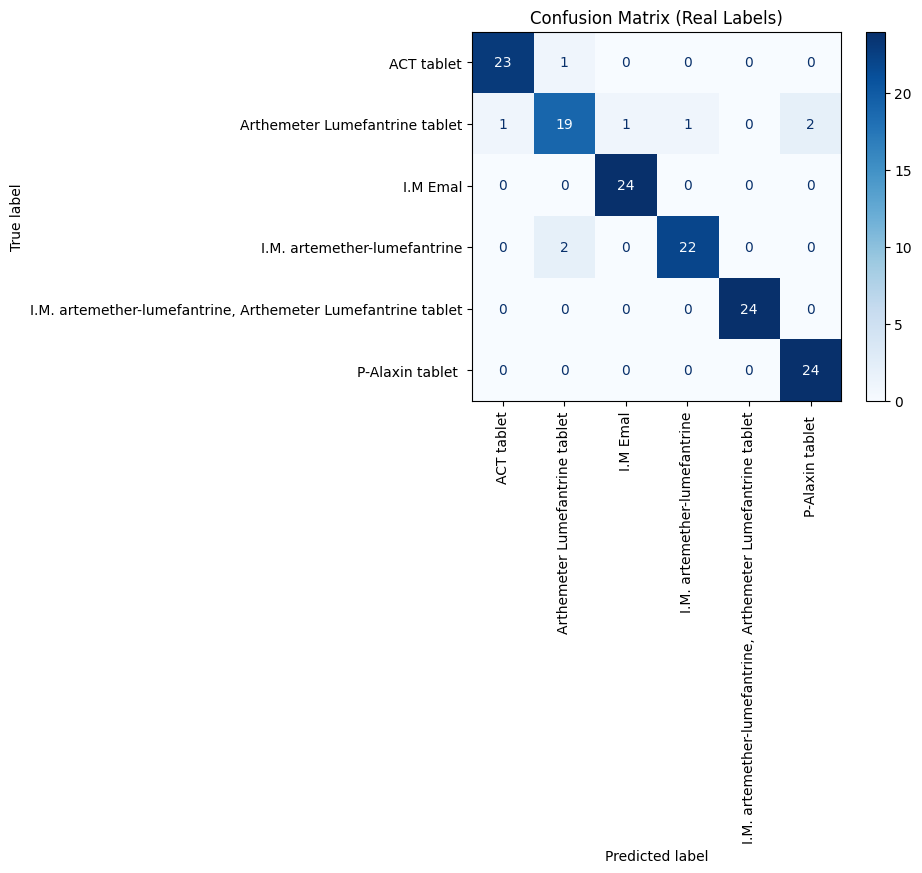

In [216]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pickle

# Recreate the label encoder to get the class names
le = LabelEncoder()
y_all = df['PRESCRIBED MEDICATION']
le.fit(y_all)
class_names = le.classes_

# Save the label encoder for the target (drug classes)
with open('le_drug.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Label encoder saved for drug classes as le_drug.pkl.")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.1, random_state=42, stratify=y_resampled
)

# Train Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix with real class labels
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=class_names)
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=90, values_format='d')
plt.title('Confusion Matrix (Real Labels)')
plt.tight_layout()
plt.show()

## Feature Importance Visualization

The following chart shows the importance of each feature in predicting the prescribed medication using the Random Forest model. This helps us understand which features contribute most to the model's decisions.

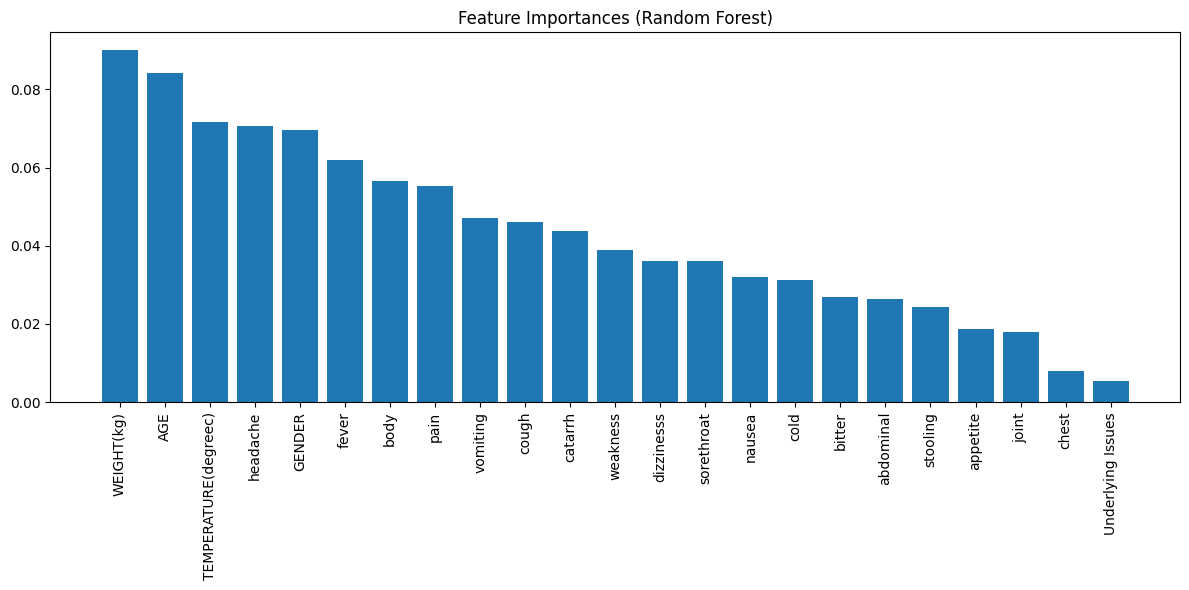

In [217]:
# Feature Importance Visualization for Random Forest
importances = clf.feature_importances_
feature_names = (
    ['AGE', 'GENDER', 'WEIGHT(kg)', 'TEMPERATURE(degreec)', 'Underlying Issues'] + list(tfidf.get_feature_names_out())
)

# Sort features by importance
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [218]:
# Save the trained model to a Pickle file
import pickle
model_filename = 'malaria_drug_recommender_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(clf, file)
print(f"Model saved to {model_filename}")

Model saved to malaria_drug_recommender_model.pkl


## Model Comparison

We will now train and compare three models: Random Forest, Decision Tree, and XGBoost. The best performing model will be saved and used in the app.

In [219]:
# Train and compare Random Forest, Decision Tree, and XGBoost
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

results = {}
best_acc = 0
best_model = None
best_model_name = ''

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name

print(f"\nBest model: {best_model_name} with accuracy {best_acc:.4f}")

# Save the best model
model_filename = 'malaria_drug_recommender_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)
print(f"Best model ({best_model_name}) saved to {model_filename}")

ModuleNotFoundError: No module named 'xgboost'